In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# YCrCb의 Y채널에 CLAHE 적용해서 국소적으로 밝기/대비 개선하는 함수
def clahe_y_channel(bgr: np.ndarray) -> np.ndarray:
    # BGR 이미지를 YCrCb 색 공간으로 변환
    ycrcb = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb)    
    # Y(밝기), Cr(빨강 색차), Cb(파랑 색차) 채널로 분리
    y, cr, cb = cv2.split(ycrcb)
    # CLAHE 객체 생성
    # - clip_limit: 대비 증폭 제한(클수록 더 강하게)
    # - tile_grid_size: 타일 크기(작을수록 더 국소적으로)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4, 4))    
    # Y 채널에만 CLAHE 적용하여 밝기/대비 개선
    y_clahe = clahe.apply(y)
    # 처리된 Y 채널과 원본 Cr, Cb 채널을 다시 병합
    ycrcb_clahe = cv2.merge([y_clahe, cr, cb])    
    # YCrCb를 다시 BGR로 변환하여 반환
    return cv2.cvtColor(ycrcb_clahe, cv2.COLOR_YCrCb2BGR)

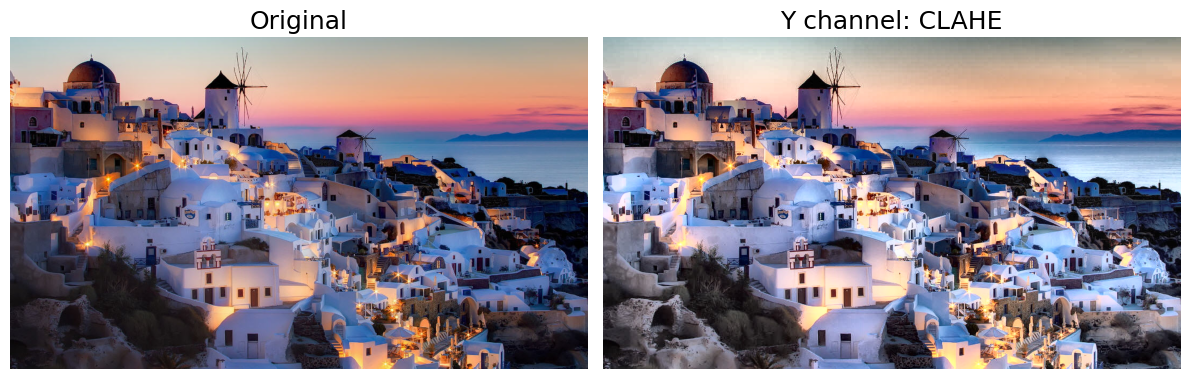

In [3]:
# 원본 이미지 불러오기
image = cv2.imread("../images/photo3.jpg")

# CLAHE 적용
result_clahe = clahe_y_channel(image)

# 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("Original", fontsize=18)
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].axis("off")

axes[1].set_title("Y channel: CLAHE", fontsize=18)
axes[1].imshow(cv2.cvtColor(result_clahe, cv2.COLOR_BGR2RGB))
axes[1].axis("off")

# 레이아웃 여백 조정
fig.tight_layout()

# 그래프 출력
plt.show()